# Gender Inequality in Education and Employment - EDA

This notebook pulls data from the World Bank WDI and ILOSTAT, runs a coverage audit and works through EDA for all three topic areas: 
**`education`**, **`labour force participation`** and **`wages`**.

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import gzip
import io
from pathlib import Path

# paths
ROOT = Path().resolve().parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "outputs" / "figures"

# create dirs if they don't exist yet
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Root: {ROOT}")

Setup complete
Root: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality


In [3]:
# Countries
COUNTRIES = {
    "NGA": "Nigeria",
    "GHA": "Ghana",
    "KEN": "Kenya",
    "ZAF": "South Africa",
    "ETH": "Ethiopia",
    "BRA": "Brazil",
    "IND": "India",
    "DEU": "Germany",
    "BGD": "Bangladesh"
}

# World Bank indicators
WB_INDICATORS = {
    # education
    "SE.ENR.PRIM.FM.ZS":  "GPI primary enrollment",
    "SE.ENR.SECO.FM.ZS":  "GPI secondary enrollment",
    "SE.ENR.TERT.FM.ZS":  "GPI tertiary enrollment",
    "SE.PRM.CMPT.FE.ZS":  "Primary completion rate female",
    "SE.PRM.CMPT.MA.ZS":  "Primary completion rate male",
    "SE.ADT.LITR.FE.ZS":  "Adult literacy rate female",
    "SE.ADT.LITR.MA.ZS":  "Adult literacy rate male",
    
    # labour force participation
    "SL.TLF.CACT.FE.ZS":  "LFP rate female",
    "SL.TLF.CACT.MA.ZS":  "LFP rate male",
    "SL.TLF.CACT.FM.ZS":  "Ratio female to male LFP",
    "SL.UEM.TOTL.FE.ZS":  "Unemployment rate female",
    "SL.UEM.TOTL.MA.ZS":  "Unemployment rate male",
}

# Period
START_YEAR = 1990
END_YEAR = 2024

print(f"Countries: {len(COUNTRIES)}")
print(f"WB indicators: {len(WB_INDICATORS)}")
print(f"Period: {START_YEAR} to {END_YEAR}")

Countries: 9
WB indicators: 12
Period: 1990 to 2024


In [4]:
WB_CACHE = DATA_RAW / "wb_raw.parquet" # set path to cache file

if WB_CACHE.exists():
    wb_raw = pd.read_parquet(WB_CACHE)
    print(f"Loaded from cache: {WB_CACHE}")
else:
    print("Pulling from World Bank API...")
    raw = wb.data.DataFrame(
        series=list(WB_INDICATORS.keys()),
        economy=list(COUNTRIES.keys()),
        time=range(START_YEAR, END_YEAR + 1),
        skipBlanks=True,
        labels=False
    )

    # wbgapi returns a MultiIndex DataFrame. melt to long form
    raw.columns.name = "year"
    raw = raw.reset_index()
    wb_raw = raw.melt(
        id_vars=["economy", "series"],
        var_name="year",
        value_name="value"
    )
    wb_raw.columns = ["country", "indicator", "year", "value"]
    wb_raw["year"] = wb_raw["year"].str.extract(r"(\d{4})").astype(int)

    wb_raw.to_parquet(WB_CACHE, index=False)
    print(f"Saved to cache: {WB_CACHE}")

print(f"Shape: {wb_raw.shape}")
print(wb_raw.head())

Loaded from cache: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality\data\raw\wb_raw.parquet
Shape: (3640, 4)
  country          indicator  year    value
0     BGD  SE.ADT.LITR.FE.ZS  1990      NaN
1     BGD  SE.ADT.LITR.MA.ZS  1990      NaN
2     BGD  SE.ENR.PRIM.FM.ZS  1990  0.84442
3     BGD  SE.ENR.SECO.FM.ZS  1990  0.50819
4     BGD  SE.ENR.TERT.FM.ZS  1990  0.18946


## World Bank data pull

Pulled 12 indicators across 9 countries from 1990 to 2024. Long form schema: 
country, indicator, year, value.

3640 rows against a theoretical max of 3780 - 140 rows dropped by skipBlanks meaning the API returned nothing for those country-indicator-year combinations. 

The coverage audit below will show exactly where the gaps sit.

In [5]:
# % of years with non-null values per country-indicator combination
total_years = END_YEAR - START_YEAR + 1

coverage = (
    wb_raw
    .groupby(["country", "indicator"])["value"]
    .apply(lambda x: x.notna().sum() / total_years * 100)
    .reset_index()
    .rename(columns={"value": "coverage_pct"})
)

# pivot to a readable heatmap shape
coverage_pivot = coverage.pivot(index="indicator", columns="country", values="coverage_pct")

# replace indicator codes with readable names
coverage_pivot.index = coverage_pivot.index.map(WB_INDICATORS)

print(coverage_pivot.round(1).to_string())

country                           BGD    BRA    DEU    ETH    GHA    IND    KEN    NGA    ZAF
indicator                                                                                    
Adult literacy rate female       40.0   60.0    NaN   22.9   14.3   34.3    2.9   17.1   34.3
Adult literacy rate male         40.0   60.0    NaN   22.9   14.3   34.3    2.9   20.0   34.3
GPI primary enrollment           34.3   54.3   82.9   91.4   77.1   82.9   65.7   80.0   80.0
GPI secondary enrollment         68.6   48.6   82.9   65.7   65.7   80.0   31.4   54.3   74.3
GPI tertiary enrollment          74.3   31.4   31.4   57.1   62.9   68.6   31.4   17.1   48.6
Primary completion rate female   22.9    NaN   68.6   65.7   62.9   48.6   14.3   22.9   42.9
Primary completion rate male     22.9    NaN   68.6   65.7   62.9   48.6   14.3   22.9   42.9
LFP rate female                 100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0
Ratio female to male LFP        100.0  100.0  100.0  100.0  

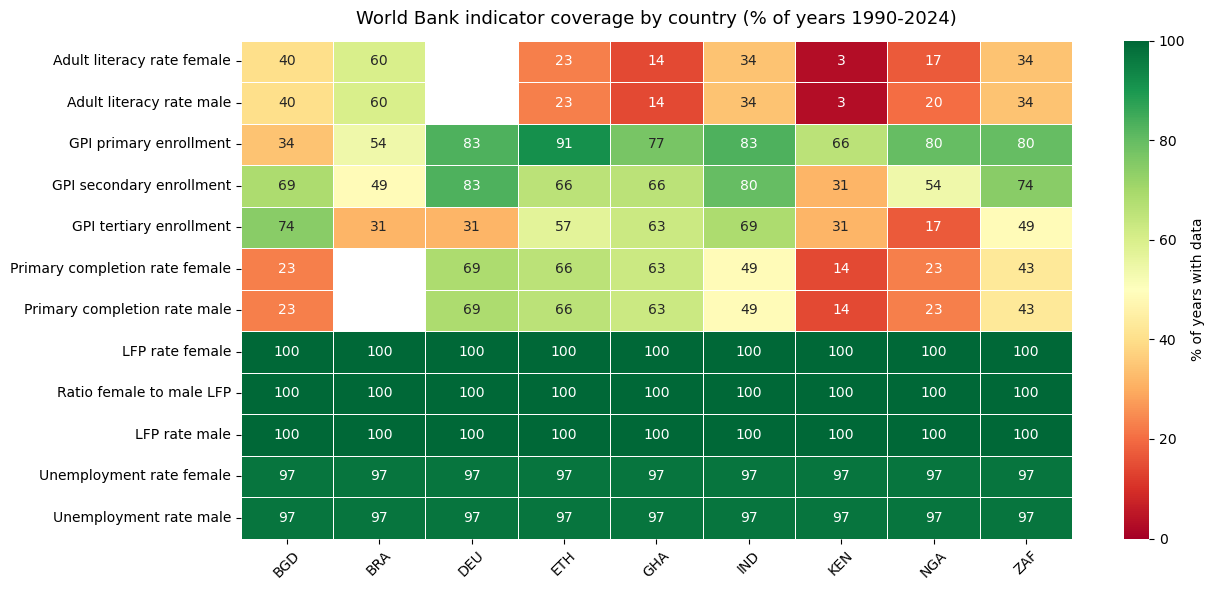

In [6]:
# visualize heatmap of coverage

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    coverage_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% of years with data"}
)

ax.set_title("World Bank indicator coverage by country (% of years 1990-2024)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "coverage_heatmap_wb.png", dpi=150, bbox_inches="tight")
plt.show()

## Coverage audit - World Bank indicators

Clear two-tier structure in the data.

LFP indicators are complete. 100% coverage across all countries and years for participation rates, 97% for unemployment. RQ2 has no data quality issues.

Education indicators are spottier. Adult literacy is effectively unusable for longitudinal analysis. Germany has no data, Kenya has 3% coverage (one point), Nigeria 17%. Primary completion rate has no Brazil data and thin coverage for Kenya and Nigeria.

The GPI enrollment indicators (primary, secondary, tertiary) are the strongest education series we have and will anchor RQ1. Literacy and completion rates will be used for descriptive context only, not in statistical tests or models.

This decision is driven by the availability of data not preference.

In [7]:
ILO_CACHE = DATA_RAW / "ilo_raw.parquet"

ILO_INDICATORS = {
    "EAR_4MTH_SEX_ECO_CUR_NB_A": "Mean monthly earnings by sex and economic activity",
    "EAR_4MTH_SEX_OCU_CUR_NB_A": "Mean monthly earnings by sex and occupation",
}

OUR_COUNTRIES = list(COUNTRIES.keys())  # ISO3 codes

def fetch_ilo_indicator(code):
    url = (
        f"https://rplumber.ilo.org/data/indicator/"
        f"?id={code}&lang=en&format=.csv"
    )
    print(f"  Fetching {code} (all countries, will filter after)...")
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
    # filter to our countries immediately - no point keeping 180+ countries
    df = df[df["ref_area"].isin(OUR_COUNTRIES)].copy()
    print(f"  Rows after country filter: {len(df)}")
    return df

if ILO_CACHE.exists():
    ilo_raw = pd.read_parquet(ILO_CACHE)
    print(f"Loaded from cache: {ILO_CACHE}")
else:
    print("Pulling from ILOSTAT API...")
    frames = []
    for code, label in ILO_INDICATORS.items():
        df = fetch_ilo_indicator(code)
        df["indicator_label"] = label
        frames.append(df)

    ilo_raw = pd.concat(frames, ignore_index=True)
    ilo_raw.to_parquet(ILO_CACHE, index=False)
    print(f"Saved to cache: {ILO_CACHE}")

print(f"\nFinal shape: {ilo_raw.shape}")
print(ilo_raw.head())

Loaded from cache: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality\data\raw\ilo_raw.parquet

Final shape: (41494, 13)
  ref_area  source                indicator    sex          classif1  \
0      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
1      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
2      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
3      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T    ECO_SECTOR_AGR   
4      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T    ECO_SECTOR_AGR   

       classif2  time  obs_value obs_status note_classif note_indicator  \
0  CUR_TYPE_LCU  2024  15516.525        NaN          NaN        T30:114   
1  CUR_TYPE_PPP  2024    470.333        NaN          NaN        T30:114   
2  CUR_TYPE_USD  2024    134.222        NaN          NaN        T30:114   
3  CUR_TYPE_LCU  2024  10965.901        NaN          NaN        T30:114   
4  CUR_TYPE_PPP  2024    332.395     

In [8]:
print("**UNIQUE INDICATORS**")
print(ilo_raw["indicator"].unique())

print("\n**UNIQUE SEX CODES**")
print(ilo_raw["sex"].unique())

print("\n**UNIQUE CURRENCY TYPES (CLASSIF2)**")
print(ilo_raw["classif2"].unique())

print("\n**UNIQUE SECTORS (CLASSIF1) - FIRST INDICATOR ONLY**")
eco = ilo_raw[ilo_raw["indicator"].str.contains("ECO")]
print(sorted(eco["classif1"].unique()))

print("\n**YEAR RANGE**")
print(f"min: {ilo_raw['time'].min()}  max: {ilo_raw['time'].max()}")

**UNIQUE INDICATORS**
<ArrowStringArray>
['EAR_EMTA_SEX_ECO_CUR_NB', 'EAR_EMTA_SEX_OCU_CUR_NB']
Length: 2, dtype: str

**UNIQUE SEX CODES**
<ArrowStringArray>
['SEX_T', 'SEX_M', 'SEX_F', 'SEX_O']
Length: 4, dtype: str

**UNIQUE CURRENCY TYPES (CLASSIF2)**
<ArrowStringArray>
['CUR_TYPE_LCU', 'CUR_TYPE_PPP', 'CUR_TYPE_USD']
Length: 3, dtype: str

**UNIQUE SECTORS (CLASSIF1) - FIRST INDICATOR ONLY**
['ECO_AGGREGATE_AGR', 'ECO_AGGREGATE_CON', 'ECO_AGGREGATE_MAN', 'ECO_AGGREGATE_MEL', 'ECO_AGGREGATE_MKT', 'ECO_AGGREGATE_PUB', 'ECO_AGGREGATE_TOTAL', 'ECO_AGGREGATE_X', 'ECO_ISIC3_A', 'ECO_ISIC3_B', 'ECO_ISIC3_C', 'ECO_ISIC3_D', 'ECO_ISIC3_E', 'ECO_ISIC3_F', 'ECO_ISIC3_G', 'ECO_ISIC3_H', 'ECO_ISIC3_I', 'ECO_ISIC3_J', 'ECO_ISIC3_K', 'ECO_ISIC3_L', 'ECO_ISIC3_M', 'ECO_ISIC3_N', 'ECO_ISIC3_O', 'ECO_ISIC3_P', 'ECO_ISIC3_Q', 'ECO_ISIC3_TOTAL', 'ECO_ISIC3_X', 'ECO_ISIC4_A', 'ECO_ISIC4_B', 'ECO_ISIC4_C', 'ECO_ISIC4_D', 'ECO_ISIC4_E', 'ECO_ISIC4_F', 'ECO_ISIC4_G', 'ECO_ISIC4_H', 'ECO_ISIC4_I', 'ECO_IS

In [9]:
# apply all four filters. currency, sex, sector classification, year range
ilo_clean = ilo_raw[
    (ilo_raw["classif2"] == "CUR_TYPE_PPP") &
    (ilo_raw["sex"].isin(["SEX_F", "SEX_M"])) &
    (ilo_raw["classif1"].str.startswith("ECO_SECTOR_")) &
    (ilo_raw["time"].between(START_YEAR, END_YEAR))
].copy()

print(f"Rows before filter: {len(ilo_raw)}")
print(f"Rows after filter:  {len(ilo_clean)}")
print(f"\nSectors remaining:")
print(sorted(ilo_clean["classif1"].unique()))
print(f"\nCountries remaining:")
print(sorted(ilo_clean["ref_area"].unique()))
print(f"\nYear range: {ilo_clean['time'].min()} to {ilo_clean['time'].max()}")

Rows before filter: 41494
Rows after filter:  1049

Sectors remaining:
['ECO_SECTOR_AGR', 'ECO_SECTOR_IND', 'ECO_SECTOR_NAG', 'ECO_SECTOR_SER', 'ECO_SECTOR_TOTAL', 'ECO_SECTOR_X']

Countries remaining:
['BGD', 'BRA', 'DEU', 'ETH', 'GHA', 'IND', 'KEN', 'NGA', 'ZAF']

Year range: 1990 to 2024


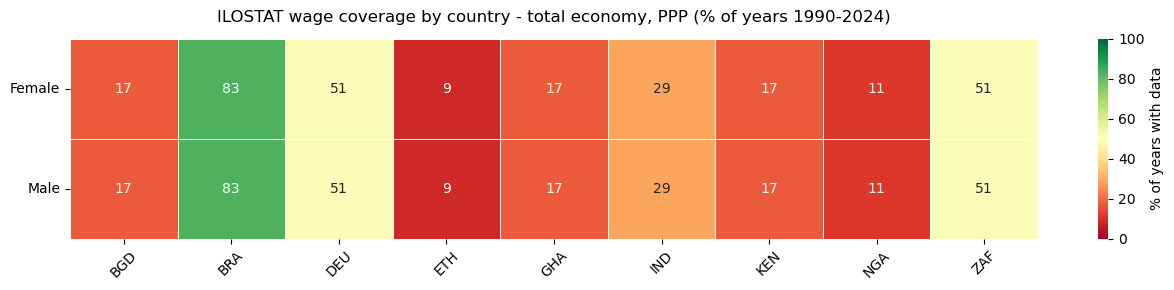

In [10]:
# coverage audit - % of years with non-null wage data per country and sex
ilo_coverage = (
    ilo_clean[ilo_clean["classif1"] == "ECO_SECTOR_TOTAL"]  # total economy only for now
    .groupby(["ref_area", "sex"])["obs_value"]
    .apply(lambda x: x.notna().sum() / (END_YEAR - START_YEAR + 1) * 100)
    .reset_index()
    .rename(columns={"obs_value": "coverage_pct"})
)

ilo_pivot = ilo_coverage.pivot(index="sex", columns="ref_area", values="coverage_pct")
ilo_pivot.index = ilo_pivot.index.map({"SEX_F": "Female", "SEX_M": "Male"})

fig, ax = plt.subplots(figsize=(13, 3))

sns.heatmap(
    ilo_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% of years with data"}
)

ax.set_title("ILOSTAT wage coverage by country - total economy, PPP (% of years 1990-2024)", fontsize=12, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "coverage_heatmap_ilo.png", dpi=150, bbox_inches="tight")
plt.show()

## ILOSTAT wage coverage audit

Coverage is thin for most African countries in our sample. Brazil is the standout at 83%. Germany and South Africa sit at 51%. Nigeria, Ethiopia, 
Ghana, Kenya and Bangladesh are all below 20% - too sparse for longitudinal regression.

Female and male coverage are identical per country - when a country reports wages it reports both sexes. The gap is a country reporting problem, not a gender reporting problem.

This directly affects RQ3. Longitudinal wage regression cannot be done on 9-17% coverage.

## RQ3 - revised approach

Wage coverage for African countries is too sparse for longitudinal regression. We proceed with pooling all available observations across years
with two fixes:

- Country fixed effects to control for within-country correlation across years
- Robust standard errors to account for heteroskedasticity

Results from RQ3 are interpreted as exploratory. Direction and magnitude of coefficients are meaningful. Precise p-values are not given 9 countries and uneven coverage. Thin African wage coverage is itself noted as a finding wage data transparency is a gender data gap.

## EDA


In [11]:
# filter to education indicators only
edu_indicators = [
    "SE.ENR.PRIM.FM.ZS",
    "SE.ENR.SECO.FM.ZS",
    "SE.ENR.TERT.FM.ZS",
    "SE.PRM.CMPT.FE.ZS",
    "SE.PRM.CMPT.MA.ZS",
    "SE.ADT.LITR.FE.ZS",
    "SE.ADT.LITR.MA.ZS",
]

edu = (
    wb_raw[wb_raw["indicator"].isin(edu_indicators)]
    .copy()
    .assign(
        indicator_label=lambda df: df["indicator"].map(WB_INDICATORS),
        country_name=lambda df: df["country"].map(COUNTRIES)
    )
    .dropna(subset=["value"])
)

print(f"Shape: {edu.shape}")
print(f"\nIndicators: {edu['indicator_label'].unique()}")
print(f"\nCountries: {edu['country_name'].unique()}")
print(f"\nYear range: {edu['year'].min()} to {edu['year'].max()}")

Shape: (978, 6)

Indicators: <ArrowStringArray>
[        'GPI primary enrollment',       'GPI secondary enrollment',
        'GPI tertiary enrollment',     'Adult literacy rate female',
       'Adult literacy rate male', 'Primary completion rate female',
   'Primary completion rate male']
Length: 7, dtype: str

Countries: <ArrowStringArray>
[  'Bangladesh',     'Ethiopia',        'Ghana',        'India',
        'Kenya',      'Nigeria', 'South Africa',      'Germany',
       'Brazil']
Length: 9, dtype: str

Year range: 1990 to 2024


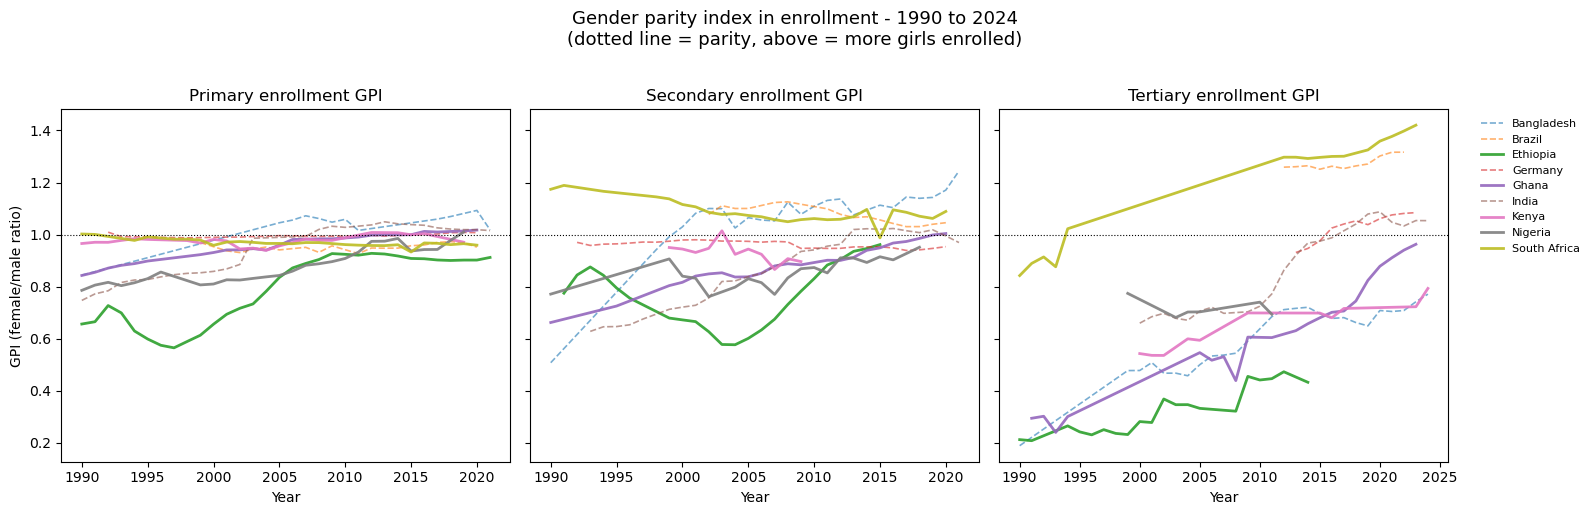

In [12]:
gpi_indicators = {
    "SE.ENR.PRIM.FM.ZS": "Primary",
    "SE.ENR.SECO.FM.ZS": "Secondary",
    "SE.ENR.TERT.FM.ZS": "Tertiary",
}

gpi = edu[edu["indicator"].isin(gpi_indicators.keys())].copy()
gpi["level"] = gpi["indicator"].map(gpi_indicators)

# split african countries vs comparators for visual clarity
african = ["Nigeria", "Ghana", "Kenya", "South Africa", "Ethiopia"]
gpi["group"] = gpi["country_name"].apply(
    lambda x: "Africa" if x in african else "Comparator"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
levels = ["Primary", "Secondary", "Tertiary"]

for ax, level in zip(axes, levels):
    data = gpi[gpi["level"] == level]
    for country, grp in data.groupby("country_name"):
        is_african = country in african
        ax.plot(
            grp["year"], grp["value"],
            linewidth=2 if is_african else 1.2,
            linestyle="-" if is_african else "--",
            alpha=0.9 if is_african else 0.6,
            label=country
        )
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{level} enrollment GPI", fontsize=12)
    ax.set_xlabel("Year")
    if ax == axes[0]:
        ax.set_ylabel("GPI (female/male ratio)")

axes[-1].legend(
    bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, frameon=False
)

fig.suptitle(
    "Gender parity index in enrollment - 1990 to 2024\n"
    "(dotted line = parity, above = more girls enrolled)",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES / "gpi_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## GPI trends - enrollment by level

**Primary:** Most countries converge toward parity by the mid-2000s. Ethiopia and Nigeria are the laggards. Nigeria closes the gap by ~2012, Ethiopia deteriorates further through the 2010s and never recovers. Bangladesh and Germany are the only countries with sustained female-majority enrollment at primary level.

**Secondary:** More dispersion. Ethiopia is the clear outlier on the low end through 2005. South Africa, Bangladesh, and Brazil flip to female-majority enrollment from around 2000 and stay there. The African countries broadly converge toward parity by 2020 but do not cross it consistently.

**Tertiary:** The most striking panel. Almost every country starts well below parity, more men in university than women. South Africa is the early exception, crossing parity before 1995 and pulling well above it by 2024. Germany and India cross parity around 2015. Ghana makes a late strong move upward. Nigeria and Ethiopia remain below parity throughout, though both show upward trends.

The gap widens as you move up the education ladder, countries that achieve primary parity do not automatically achieve secondary or tertiary parity. 
Education systems are leaky for girls at every transition point.

Sparse data visible especially at tertiary level several countries have gaps in the series. This is consistent with the coverage audit findings.

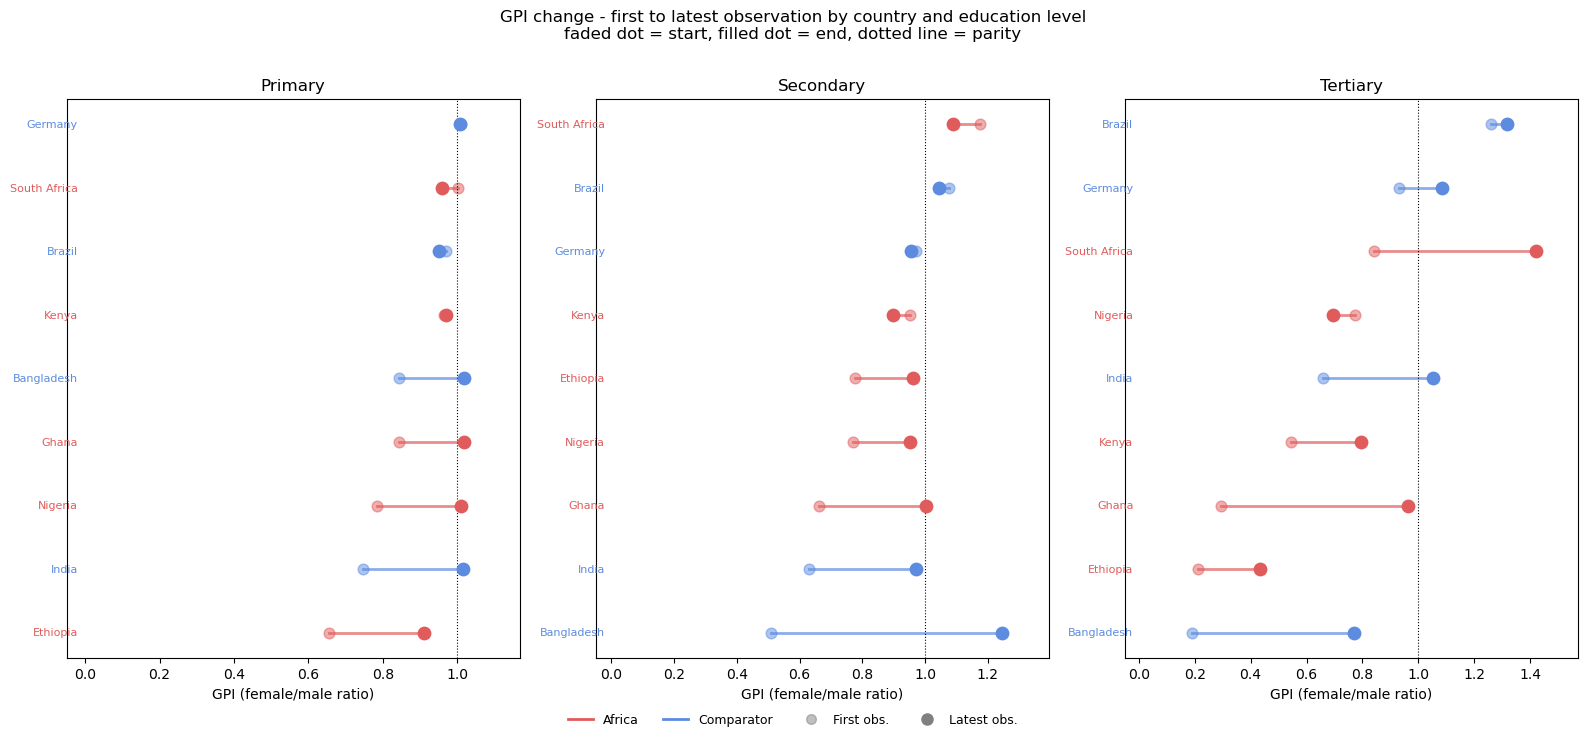

In [14]:
# compute first and last observed GPI per country per level
slope_data = []

for indicator, level in gpi_indicators.items():
    for country, grp in gpi[gpi["indicator"] == indicator].groupby("country_name"):
        grp_sorted = grp.dropna(subset=["value"]).sort_values("year")
        if len(grp_sorted) < 2:
            continue
        slope_data.append({
            "country": country,
            "level": level,
            "start_year": grp_sorted["year"].iloc[0],
            "end_year": grp_sorted["year"].iloc[-1],
            "start_val": grp_sorted["value"].iloc[0],
            "end_val": grp_sorted["value"].iloc[-1],
            "group": "Africa" if country in african else "Comparator"
        })

slope_df = pd.DataFrame(slope_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=False)

for ax, level in zip(axes, ["Primary", "Secondary", "Tertiary"]):
    data = slope_df[slope_df["level"] == level].sort_values("start_val")

    for i, (_, row) in enumerate(data.iterrows()):
        color = "#e05c5c" if row["group"] == "Africa" else "#5c8be0"

        # connecting line
        ax.plot(
            [row["start_val"], row["end_val"]], [i, i],
            color=color, linewidth=2, alpha=0.7, zorder=1
        )
        # start dot
        ax.scatter(
            row["start_val"], i,
            color=color, s=60, zorder=2,
            marker="o", alpha=0.5, label="_nolegend_"
        )
        # end dot - filled
        ax.scatter(
            row["end_val"], i,
            color=color, s=80, zorder=3,
            marker="o", label="_nolegend_"
        )
        # country label
        ax.text(
            -0.02, i, row["country"],
            ha="right", va="center",
            fontsize=8, color=color
        )

    ax.axvline(1.0, color="black", linewidth=0.8, linestyle=":")
    ax.set_yticks([])
    ax.set_xlabel("GPI (female/male ratio)")
    ax.set_title(f"{level}", fontsize=12)
    ax.set_xlim(-0.05, max(data["end_val"].max(), data["start_val"].max()) + 0.15)

# shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#e05c5c", linewidth=2, label="Africa"),
    Line2D([0], [0], color="#5c8be0", linewidth=2, label="Comparator"),
    Line2D([0], [0], color="grey", linewidth=0, marker="o",
           markerfacecolor="grey", alpha=0.5, markersize=7, label="First obs."),
    Line2D([0], [0], color="grey", linewidth=0, marker="o",
           markerfacecolor="grey", markersize=8, label="Latest obs."),
]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=4,
    fontsize=9, frameon=False,
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "GPI change - first to latest observation by country and education level\n"
    "faded dot = start, filled dot = end, dotted line = parity",
    fontsize=12, y=1.01
)

plt.tight_layout()
plt.savefig(FIGURES / "gpi_dumbbell.png", dpi=150, bbox_inches="tight")
plt.show()

## GPI dumbbell - progress from first to latest observation

**Primary:** The primary story is largely one of convergence. Germany starts at parity so no gap to close, hence minimal movement. South Africa, Nigeria, Ghana, Bangladesh, and India all start below parity and reach it by their latest observation. Ethiopia is the outlier, lowest starting point of any country and the only one that fails to reach parity despite meaningful improvement. Kenya and Brazil show the least movement, starting close to parity and staying there.

**Secondary:** South Africa and Germany start above parity and extend further, girls already outnumber boys and the gap widens. Bangladesh is the standout achiever, moving from ~0.5 to ~1.2 - the largest absolute gain in the dataset. Ghana also closes the gap to reach parity. Kenya, Ethiopia, Nigeria, and India all improve but fall short of parity at their latest observation.

**Tertiary:** The hardest level to crack. Brazil is the only country that starts at parity already achieved before 1990. Germany and India both start below and cross parity by their latest observation, with India making the steeper climb. South Africa crosses parity and keeps going to 1.4, the highest tertiary GPI in the dataset. Ghana makes a strong move but just falls short. Ethiopia and Bangladesh both start near the floor (~0.2). Ethiopia reaches only 0.4 while Bangladesh more than doubles to ~0.8 despite a 
similar starting point.

The ladder effect is clear: achieving primary parity does not guarantee secondary parity, and secondary parity does not guarantee tertiary parity. Girls face compounding barriers at each transition point, and the gap widens at higher education levels across almost every country in the sample.

## LFP EDA

In [15]:
lfp_indicators = [
    "SL.TLF.CACT.FE.ZS",
    "SL.TLF.CACT.MA.ZS",
    "SL.TLF.CACT.FM.ZS",
    "SL.UEM.TOTL.FE.ZS",
    "SL.UEM.TOTL.MA.ZS",
]

lfp = (
    wb_raw[wb_raw["indicator"].isin(lfp_indicators)]
    .copy()
    .assign(
        indicator_label=lambda df: df["indicator"].map(WB_INDICATORS),
        country_name=lambda df: df["country"].map(COUNTRIES)
    )
    .dropna(subset=["value"])
)

print(f"Shape: {lfp.shape}")
print(f"\nYear range: {lfp['year'].min()} to {lfp['year'].max()}")
print(f"\nCountries: {list(lfp['country_name'].unique())}")

Shape: (1557, 6)

Year range: 1990 to 2024

Countries: ['Bangladesh', 'Brazil', 'Germany', 'Ethiopia', 'Ghana', 'India', 'Kenya', 'Nigeria', 'South Africa']


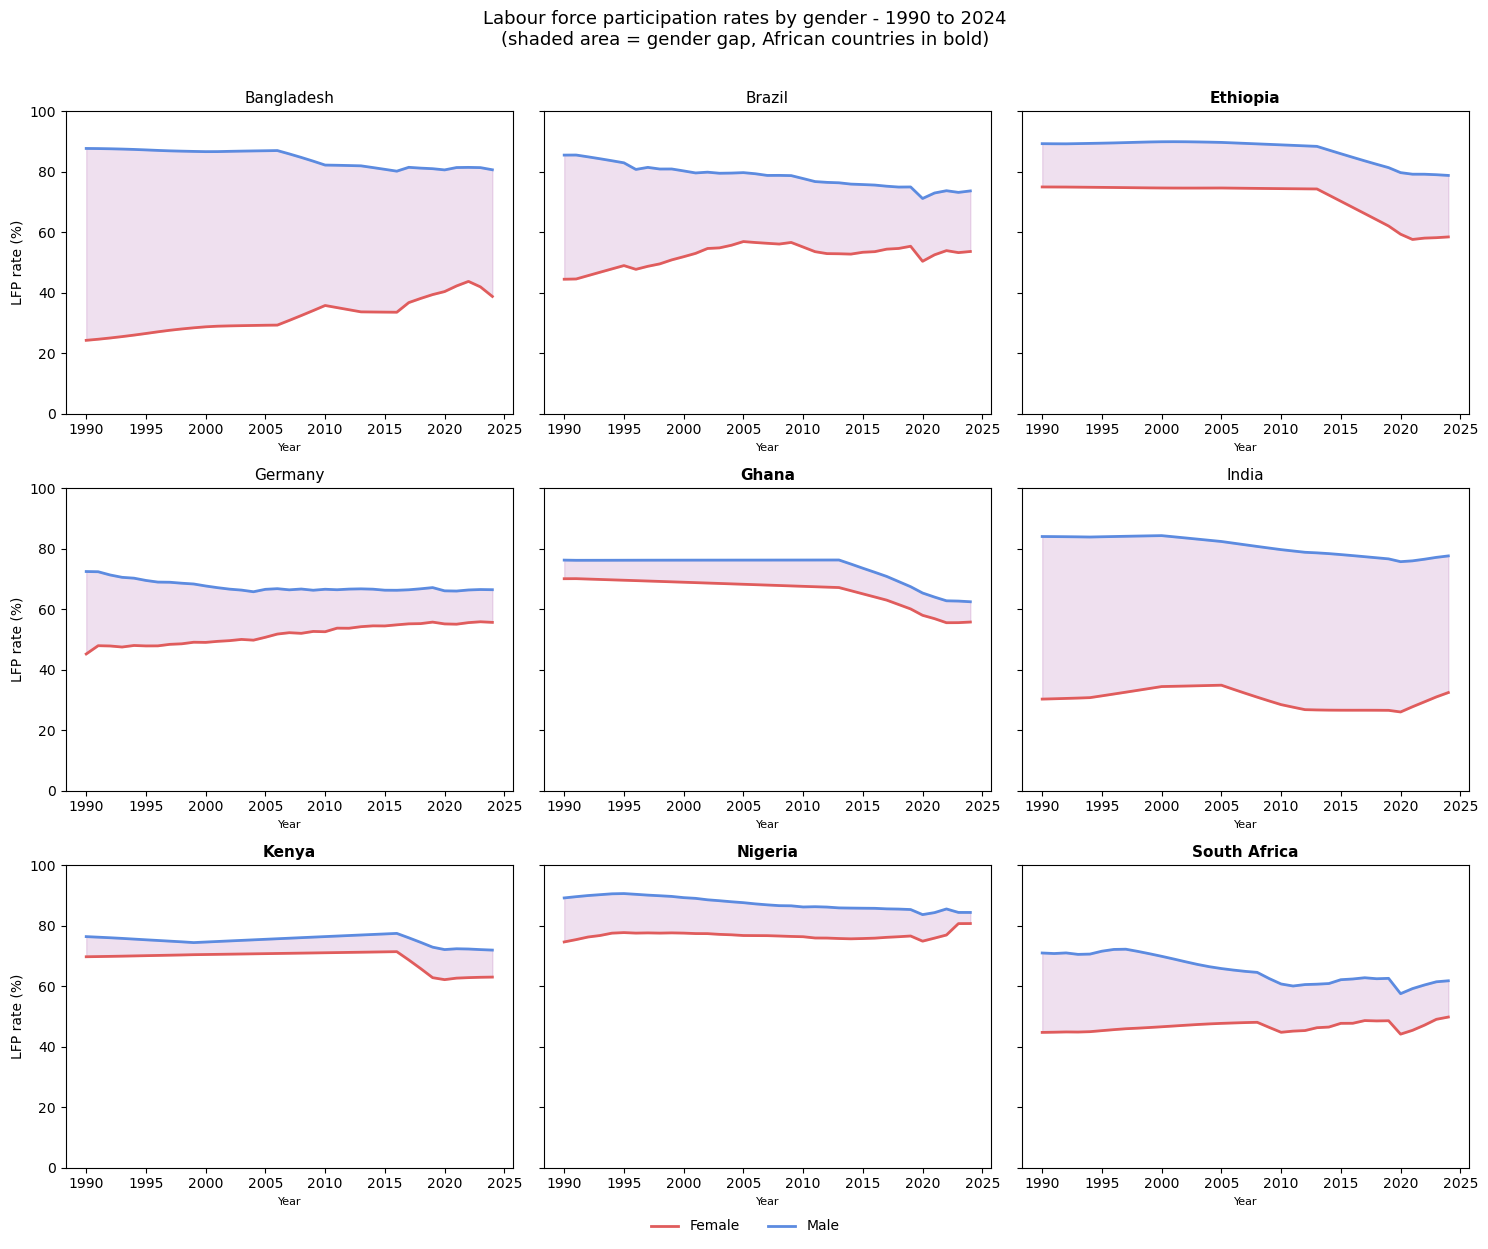

In [16]:
lfp_rates = lfp[lfp["indicator"].isin([
    "SL.TLF.CACT.FE.ZS",
    "SL.TLF.CACT.MA.ZS"
])].copy()

lfp_rates["sex"] = lfp_rates["indicator"].map({
    "SL.TLF.CACT.FE.ZS": "Female",
    "SL.TLF.CACT.MA.ZS": "Male"
})

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
axes = axes.flatten()

for i, (country, grp) in enumerate(lfp_rates.groupby("country_name")):
    ax = axes[i]
    for sex, sgrp in grp.groupby("sex"):
        color = "#e05c5c" if sex == "Female" else "#5c8be0"
        ax.plot(sgrp["year"], sgrp["value"],
                color=color, linewidth=2, label=sex)

    # shade the gap
    female = grp[grp["sex"] == "Female"].set_index("year")["value"]
    male = grp[grp["sex"] == "Male"].set_index("year")["value"]
    common_years = female.index.intersection(male.index)
    ax.fill_between(
        common_years,
        female[common_years],
        male[common_years],
        alpha=0.12, color="purple"
    )

    is_african = country in african
    ax.set_title(
        country,
        fontsize=11,
        fontweight="bold" if is_african else "normal"
    )
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("LFP rate (%)" if i % 3 == 0 else "")
    ax.set_ylim(0, 100)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=2,
    fontsize=10, frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Labour force participation rates by gender - 1990 to 2024\n"
    "(shaded area = gender gap, African countries in bold)",
    fontsize=13, y=1.01
)

plt.tight_layout()
plt.savefig(FIGURES / "lfp_trends.png", dpi=150, bbox_inches="tight")
plt.show()

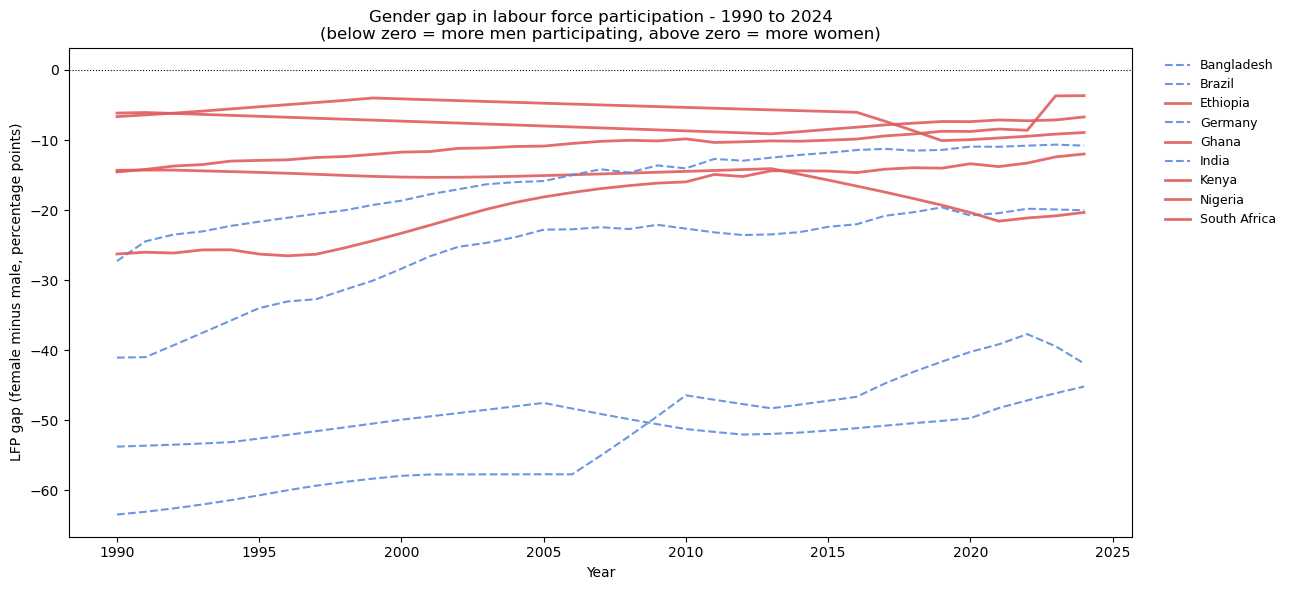

In [17]:
# compute gender gap as female minus male LFP rate
female_lfp = (
    lfp[lfp["indicator"] == "SL.TLF.CACT.FE.ZS"]
    .set_index(["country_name", "year"])["value"]
    .rename("female")
)
male_lfp = (
    lfp[lfp["indicator"] == "SL.TLF.CACT.MA.ZS"]
    .set_index(["country_name", "year"])["value"]
    .rename("male")
)

lfp_gap = (
    pd.concat([female_lfp, male_lfp], axis=1)
    .dropna()
    .assign(gap=lambda df: df["female"] - df["male"])
    .reset_index()
    .assign(group=lambda df: df["country_name"].apply(
        lambda x: "Africa" if x in african else "Comparator"
    ))
)

fig, ax = plt.subplots(figsize=(13, 6))

for country, grp in lfp_gap.groupby("country_name"):
    is_african = country in african
    color = "#e05c5c" if is_african else "#5c8be0"
    ax.plot(
        grp["year"], grp["gap"],
        color=color,
        linewidth=2 if is_african else 1.5,
        linestyle="-" if is_african else "--",
        alpha=0.9,
        label=country
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylabel("LFP gap (female minus male, percentage points)")
ax.set_xlabel("Year")
ax.set_title(
    "Gender gap in labour force participation - 1990 to 2024\n"
    "(below zero = more men participating, above zero = more women)",
    fontsize=12
)

# split legend into two columns - africa and comparators
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=9, frameon=False
)

plt.tight_layout()
plt.savefig(FIGURES / "lfp_gap_trends.png", dpi=150, bbox_inches="tight")
plt.show()

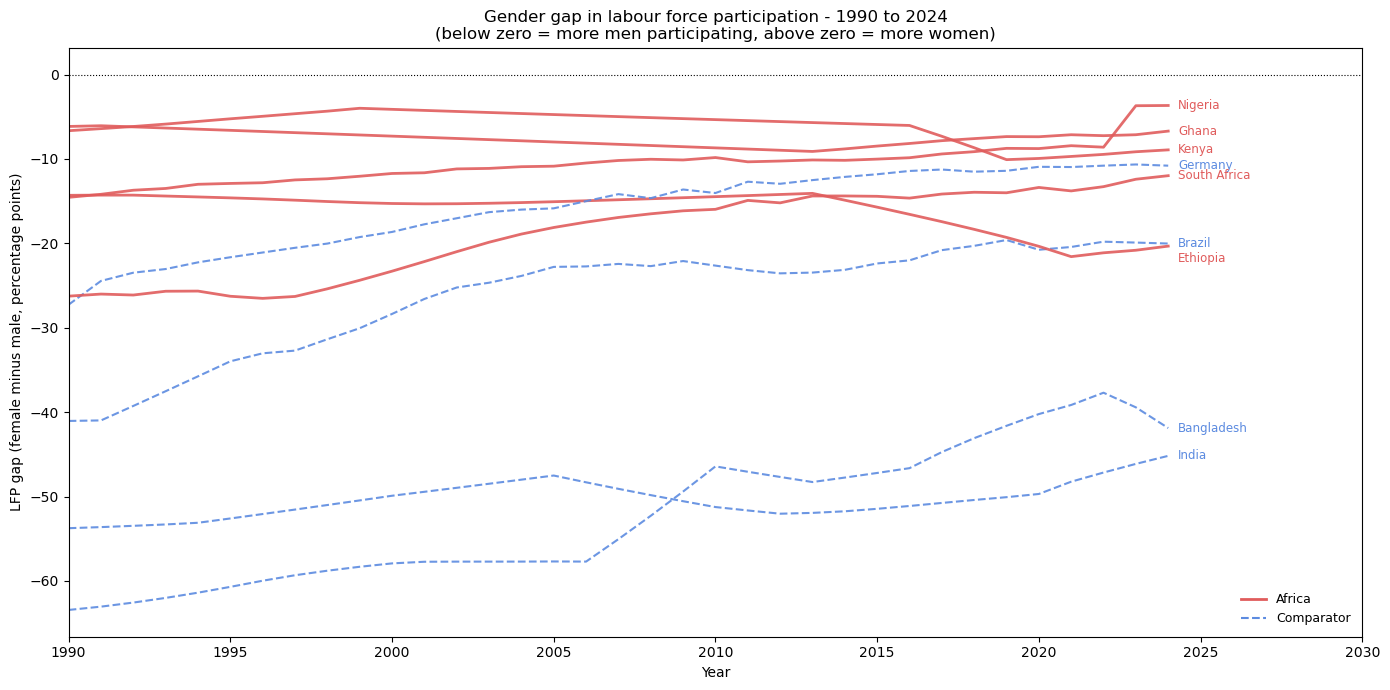

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))

for country, grp in lfp_gap.groupby("country_name"):
    is_african = country in african
    color = "#e05c5c" if is_african else "#5c8be0"
    ax.plot(
        grp["year"], grp["gap"],
        color=color,
        linewidth=2 if is_african else 1.5,
        linestyle="-" if is_african else "--",
        alpha=0.9,
    )
    # label at the end of each line
    last = grp.sort_values("year").iloc[-1]
    offset = -1.5 if country == "Ethiopia" else 0
    ax.text(
        last["year"] + 0.3, last["gap"] + offset,
        country,
        fontsize=8.5,
        color=color,
        va="center"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylabel("LFP gap (female minus male, percentage points)")
ax.set_xlabel("Year")
ax.set_xlim(1990, 2030)  # extra space for labels
ax.set_title(
    "Gender gap in labour force participation - 1990 to 2024\n"
    "(below zero = more men participating, above zero = more women)",
    fontsize=12
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#e05c5c", linewidth=2, label="Africa"),
    Line2D([0], [0], color="#5c8be0", linewidth=1.5,
           linestyle="--", label="Comparator"),
]
ax.legend(handles=legend_elements, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(FIGURES / "lfp_gap_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## LFP gender gap trends - 1990 to 2024

All countries are below zero throughout the entire period meaning men participate in the labour force more than women everywhere in our sample without exception.

African countries cluster tightly between -5 and -20 percentage points, with Germany being the only comparator that joins this group. Bangladesh  and India sit far below, starting at -63 and -55 respectively in 1990.

The smaller African gap is real in the data but context matters. The ILO definition of labour force includes any work of at least one hour which means things like subsistence farming, informal trade, unpaid family farm work all count. High female LFP in African countries reflects the prevalence of informal and subsistence work, not necessarily lower structural barriers to employment. Whether policy or economic necessity drives this is a question our data cannot directly answer.

Bangladesh is the standout improver, narrowing its gap by roughly 21 percentage points since 1990, the largest absolute improvement in the dataset. This is consistent with what we saw in education. Bangladesh also made the biggest secondary enrollment GPI gain. India by contrast barely moves despite a similar starting point - the gap in 2024 is nearly identical to 1990.

Ethiopia is the only African country that worsens over the period, its gap widening after 2015, consistent with the education story where Ethiopia was also the weakest performer.

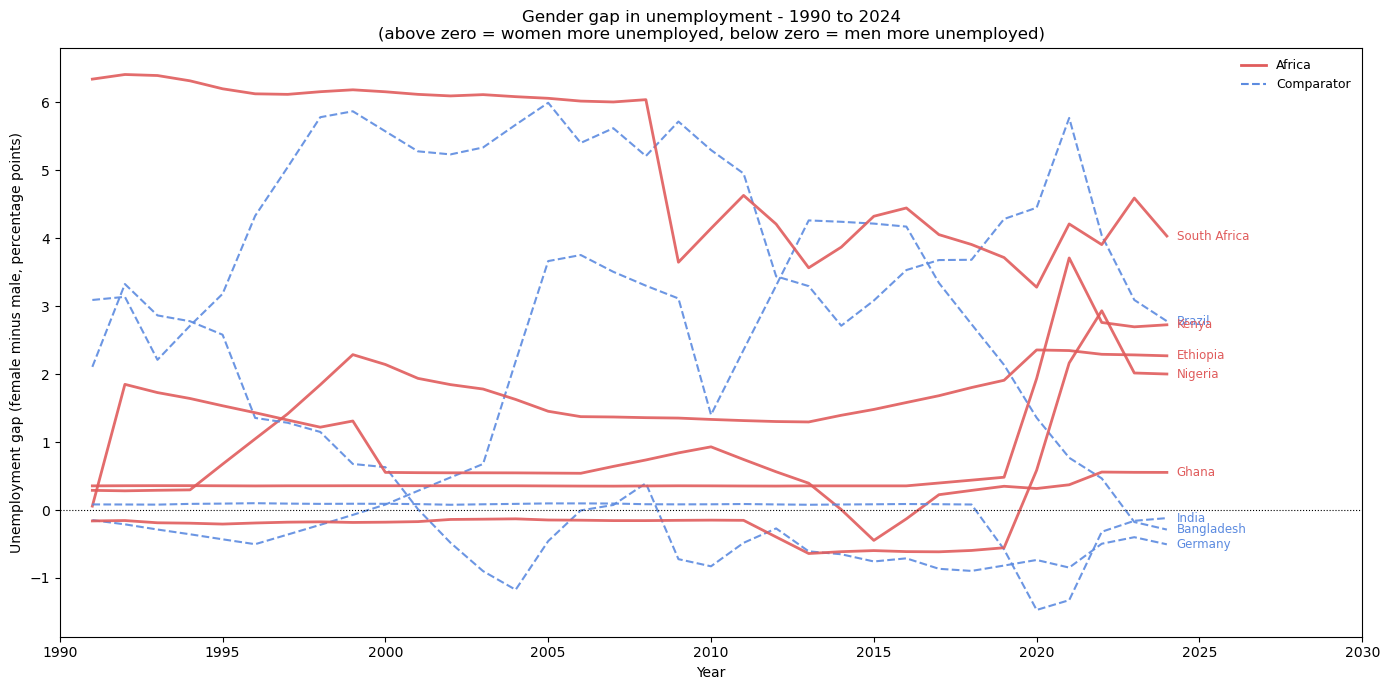

In [19]:
# compute unemployment gap - female minus male
female_uem = (
    lfp[lfp["indicator"] == "SL.UEM.TOTL.FE.ZS"]
    .set_index(["country_name", "year"])["value"]
    .rename("female")
)
male_uem = (
    lfp[lfp["indicator"] == "SL.UEM.TOTL.MA.ZS"]
    .set_index(["country_name", "year"])["value"]
    .rename("male")
)

uem_gap = (
    pd.concat([female_uem, male_uem], axis=1)
    .dropna()
    .assign(gap=lambda df: df["female"] - df["male"])
    .reset_index()
    .assign(group=lambda df: df["country_name"].apply(
        lambda x: "Africa" if x in african else "Comparator"
    ))
)

fig, ax = plt.subplots(figsize=(14, 7))

for country, grp in uem_gap.groupby("country_name"):
    is_african = country in african
    color = "#e05c5c" if is_african else "#5c8be0"
    ax.plot(
        grp["year"], grp["gap"],
        color=color,
        linewidth=2 if is_african else 1.5,
        linestyle="-" if is_african else "--",
        alpha=0.9,
    )
    last = grp.sort_values("year").iloc[-1]
    ax.text(
        last["year"] + 0.3, last["gap"],
        country,
        fontsize=8.5,
        color=color,
        va="center"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylabel("Unemployment gap (female minus male, percentage points)")
ax.set_xlabel("Year")
ax.set_xlim(1990, 2030)
ax.set_title(
    "Gender gap in unemployment - 1990 to 2024\n"
    "(above zero = women more unemployed, below zero = men more unemployed)",
    fontsize=12
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#e05c5c", linewidth=2, label="Africa"),
    Line2D([0], [0], color="#5c8be0", linewidth=1.5,
           linestyle="--", label="Comparator"),
]
ax.legend(handles=legend_elements, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(FIGURES / "unemployment_gap_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## Gender gap in unemployment - 1990 to 2024

Unlike the LFP gap chart which showed a clean structural split, unemployment gaps are noisier, most countries fluctuate around zero throughout the period rather than sitting persistently on one side.

A few patterns stand out:

- Nigeria sits below zero for most of the period up to 2019, meaning more women than men were unemployed then spikes sharply around 2020. Kenya shows a similar spike at the same point. The 2020 signal is visible across multiple countries and is consistent with COVID-19 disruptions hitting female employment harder than male employment in those economies.

- India is the counterintuitive case it spikes in the opposite direction around 2019 to 2020, meaning the crisis period saw relatively more men unemployed than women. Germany shows a similar dip in the same period. A possible explanation is that women were more concentrated in sectors that stayed active during lockdowns like healthcare, essential retail but our data cannot confirm this directly.

- Bangladesh starts below zero in 1990 (more women unemployed), crosses toward zero around 2000, and returns below zero by 2024. Consistent with the broader Bangladesh story of improving female economic outcomes over the period.

- Most countries spend most of the period close to zero the unemployment gap is smaller and less stable than the LFP participation gap. The bigger gender story in this dataset is who participates, not who is unemployed among those who do.

## WAGE

In [20]:
# wages EDA - work with the filtered ilo data
# reminder: PPP, female/male only, ECO_SECTOR_* classification, 1990-2024

print("**SHAPE**")
print(ilo_clean.shape)

print("\n**COUNTRIES AND ROW COUNTS**")
print(ilo_clean.groupby("ref_area")["obs_value"].count())

print("\n**SECTORS**")
print(ilo_clean["classif1"].unique())

print("\n**YEAR RANGE PER COUNTRY**")
print(
    ilo_clean.groupby("ref_area")["time"]
    .agg(["min", "max", "count"])
)

**SHAPE**
(1049, 13)

**COUNTRIES AND ROW COUNTS**
ref_area
BGD     62
BRA    340
DEU    208
ETH     30
GHA     62
IND    102
KEN     31
NGA     37
ZAF    177
Name: obs_value, dtype: int64

**SECTORS**
<ArrowStringArray>
['ECO_SECTOR_TOTAL',   'ECO_SECTOR_AGR',   'ECO_SECTOR_NAG',
   'ECO_SECTOR_IND',   'ECO_SECTOR_SER',     'ECO_SECTOR_X']
Length: 6, dtype: str

**YEAR RANGE PER COUNTRY**
           min   max  count
ref_area                   
BGD       2013  2024     62
BRA       1995  2024    340
DEU       1999  2022    208
ETH       2005  2021     30
GHA       2013  2024     62
IND       2005  2024    102
KEN       1990  2019     31
NGA       2011  2024     37
ZAF       2000  2020    177
